In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
import torch
from twfv import run_em_like
from twfv.simulate import simulate_factor_data_bspline
from twfv.cp import NaiveAbsoluteResidualCP, unflatten


def flatten(i: int, j: int, t: int, I: int, J: int, T: int) -> int:
    return i * (J * T) + j * T + t

In [2]:
def local_var_Y_from_info(info):
    """
    Compute per-subject/time/channel innovation variance:
      Var[epsilon_{i,t,j}] = kappa_i * sum_k X_{j,k}^2 * a2_{i,t,k} + s_i^2 * Psi_j

    Returns:
        var: array (I, T, J)
    """
    X = np.asarray(info["X_true"], dtype=float)          # (J, r)
    Psi = np.asarray(info["Psi_true"], dtype=float)      # (J,)
    s = np.asarray(info["s_true"], dtype=float)          # (I,)
    kappa = np.asarray(info["kappa_true"], dtype=float)  # (I,)
    a2 = np.asarray(info["a2_true"], dtype=float)        # (I, T, r) or (T, r)

    if a2.ndim == 2:  # allow (T, r) broadcast to subjects
        a2 = a2[None, ...]

    Xsq = X ** 2                     # (J, r)
    print(Xsq)
    base = np.einsum("itr,jr->itj", a2, Xsq)  # sum_k X_{j,k}^2 * a2_{i,t,k}, shape (I, T, J)
    print(np.cov(a2[0,:,0],a2[0,:,1]))
    print(a2[0,:30,0])
    print(base[0,:30,0])
    print(base[0,:30,0]*kappa[0])
    print(s[0]**2*Psi[0])
    var = kappa[:, None, None] * base + (s ** 2)[:, None, None] * Psi[None, None, :]
    print(var[0,:30,0])
    return var  # (I, T, J)

array([0.2 , 0.35, 0.5 , 0.65, 0.8 ])

In [6]:
I, T, J, r, M_ctrl = 10, 100, 5, 2, 10
rng = np.random.default_rng(0)
kappa_true = np.exp(rng.normal(2, .5, size=I))
C_true=rng.normal(scale=3, size=(I, r, M_ctrl))
miss_prob_per_channel=np.linspace(0.1,0.4,J)
Y, M, info = simulate_factor_data_bspline(
    I, T, J, r, M_ctrl=M_ctrl, degree=3, seed=1, use_variance_tied_missing=False,miss_prob_per_channel=miss_prob_per_channel,kappa_true=kappa_true,C_true=C_true
)
local_var_Y=local_var_Y_from_info(info)

[[0.34231833 0.60003552]
 [0.32785311 1.10836175]
 [1.09588937 0.31120189]
 [0.55196603 0.40410339]
 [0.3608928  0.2208153 ]]
[[ 3.98012312 -0.51388349]
 [-0.51388349  1.86324038]]
[0.12918709 0.15748786 0.17225634 0.16627561 0.13793732 0.10759122
 0.07610878 0.04699196 0.02916195 0.01829958 0.01255045 0.00969907
 0.00845926 0.00861437 0.00986731 0.01251722 0.01726933 0.02445742
 0.03544155 0.04983194 0.06475937 0.07476689 0.07760278 0.06666147
 0.04927258 0.03638995 0.03012591 0.03005697 0.03442029 0.04225123]
[0.5337649  1.01789388 1.58600402 2.18501107 2.60662083 2.67819762
 2.3833751  1.85588857 1.32182024 0.90262943 0.59916089 0.41805813
 0.31376707 0.26673584 0.24979188 0.25825508 0.29145873 0.35266646
 0.45283952 0.59275498 0.78449059 1.03388849 1.32819447 1.63246733
 1.9862031  2.30458595 2.56986657 2.7548703  2.82577934 2.74259018]
[ 4.19991933  8.0092793  12.47944346 17.19271943 20.51014809 21.07334877
 18.75354314 14.6030251  10.40071825  7.10232308  4.71448644  3.2894827
  

In [16]:
local_var_Y.round(3)[0, :, 0]

array([ 4.567,  8.377, 12.847, 17.56 , 20.878, 21.441, 19.121, 14.971,
       10.768,  7.47 ,  5.082,  3.657,  2.836,  2.466,  2.333,  2.4  ,
        2.661,  3.142,  3.931,  5.032,  6.54 ,  8.503, 10.818, 13.213,
       15.996, 18.501, 20.588, 22.044, 22.602, 21.948, 20.4  , 18.078,
       15.788, 13.21 , 10.716,  8.702,  7.074,  5.703,  4.613,  3.787,
        3.123,  2.685,  2.373,  2.136,  1.969,  1.848,  1.768,  1.729,
        1.631,  1.598,  1.612,  1.648,  1.722,  1.814,  1.946,  2.089,
        2.204,  2.349,  2.572,  2.734,  2.849,  2.981,  3.112,  3.244,
        3.38 ,  3.486,  3.559,  3.595,  3.694,  3.697,  3.718,  3.733,
        3.74 ,  3.761,  3.777,  3.844,  3.847,  3.901,  3.993,  4.052,
        4.055,  4.083,  4.279,  4.391,  4.503,  4.704,  4.934,  5.316,
        5.719,  6.211,  6.76 ,  7.648,  8.541, 10.084, 12.419, 14.675,
       17.308, 22.672, 32.391, 43.678])

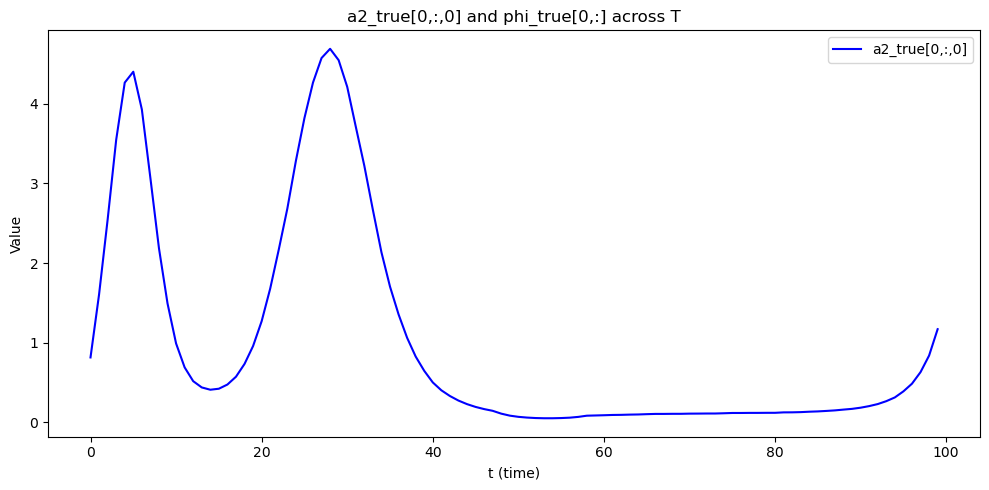

In [7]:
a2_true=info['a2_true']

T_range = np.arange(T)
plt.figure(figsize=(10, 5))
plt.plot(T_range, a2_true[0, :, 1], label='a2_true[0,:,0]', color='blue')
plt.xlabel('t (time)')
plt.ylabel('Value')
plt.title('a2_true[0,:,0] and phi_true[0,:] across T')
plt.legend()
plt.tight_layout()
plt.show()

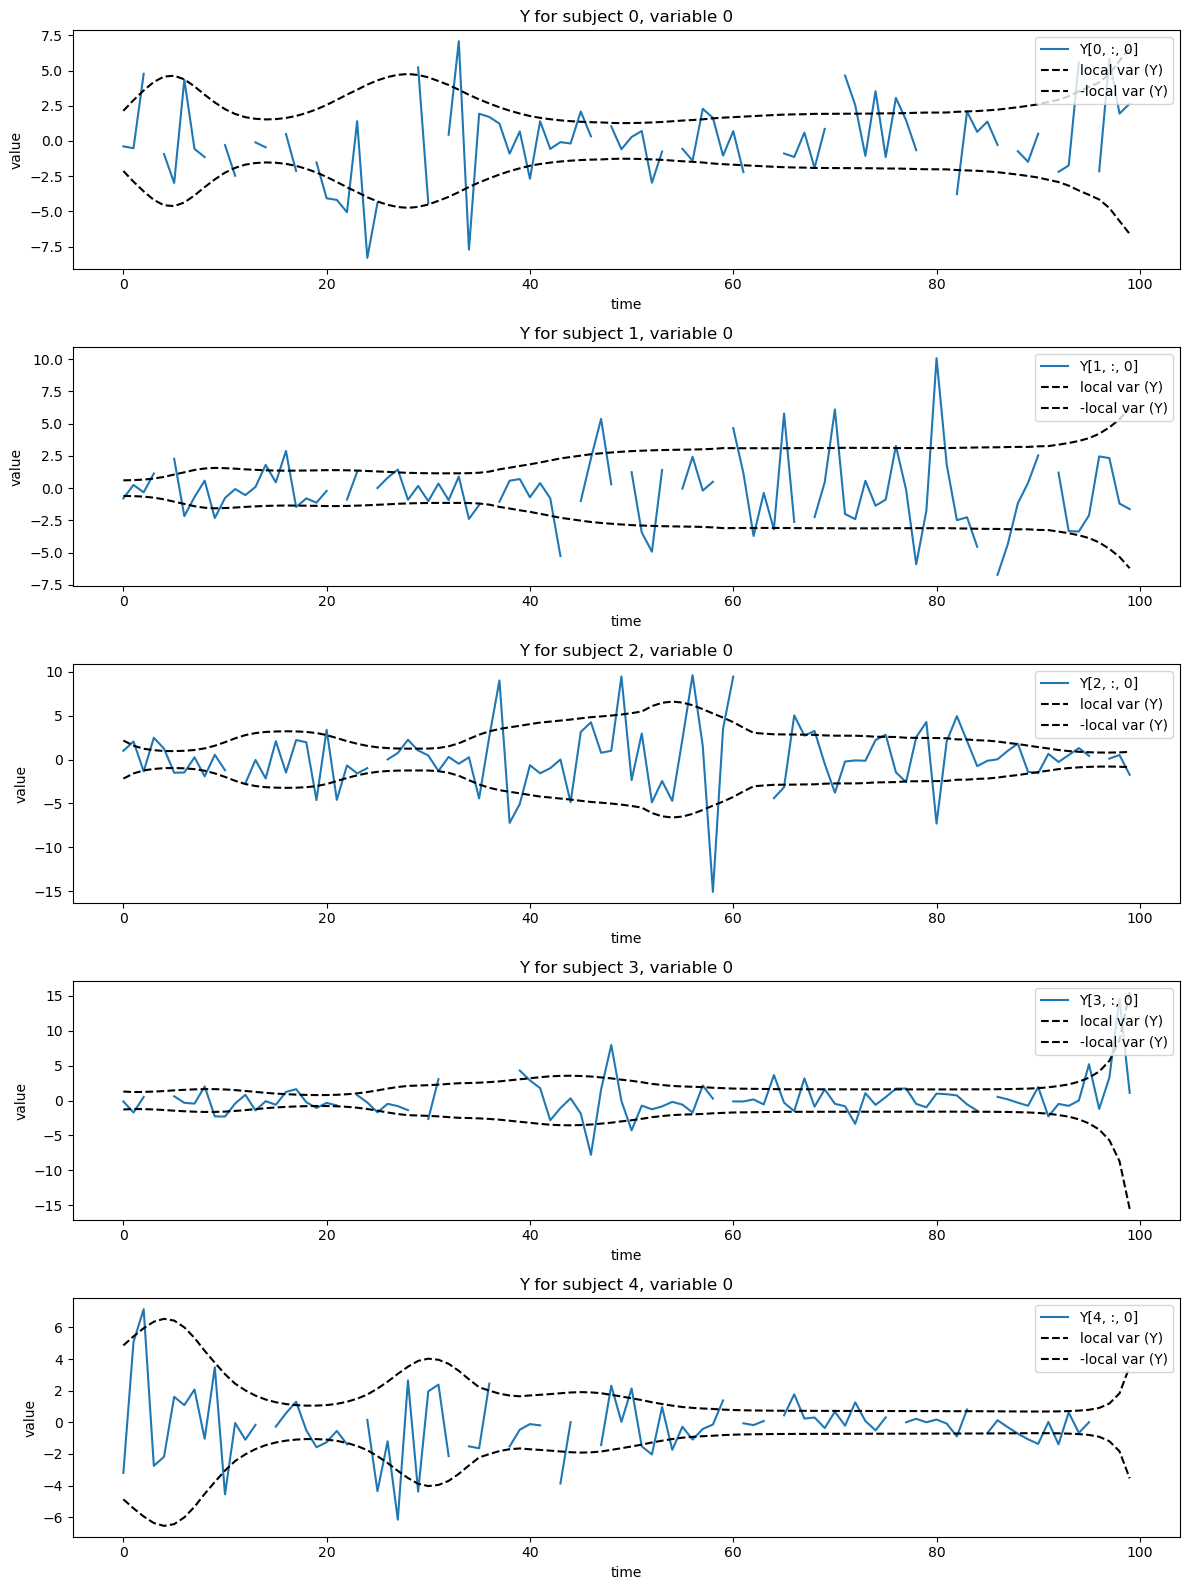

In [8]:

import copy
# Plot Y0 for subjects 0-4
plt.figure(figsize=(12, 16))
YM=copy.deepcopy(Y)
YM[M==False]=np.nan
for i in range(5):
    plt.subplot(5, 1, i + 1)
    plt.plot(YM[i, :, 0], label=f"Y[{i}, :, 0]")
    var = local_var_Y[i, :, 0]  # shape (T,)
    plt.plot(np.sqrt(var), 'k--', label='local var (Y)')
    plt.plot(-np.sqrt(var), 'k--', label='-local var (Y)')
    plt.title(f"Y for subject {i}, variable 0")
    plt.xlabel("time")
    plt.ylabel("value")
    plt.legend(loc='upper right')
    plt.tight_layout()
plt.show()


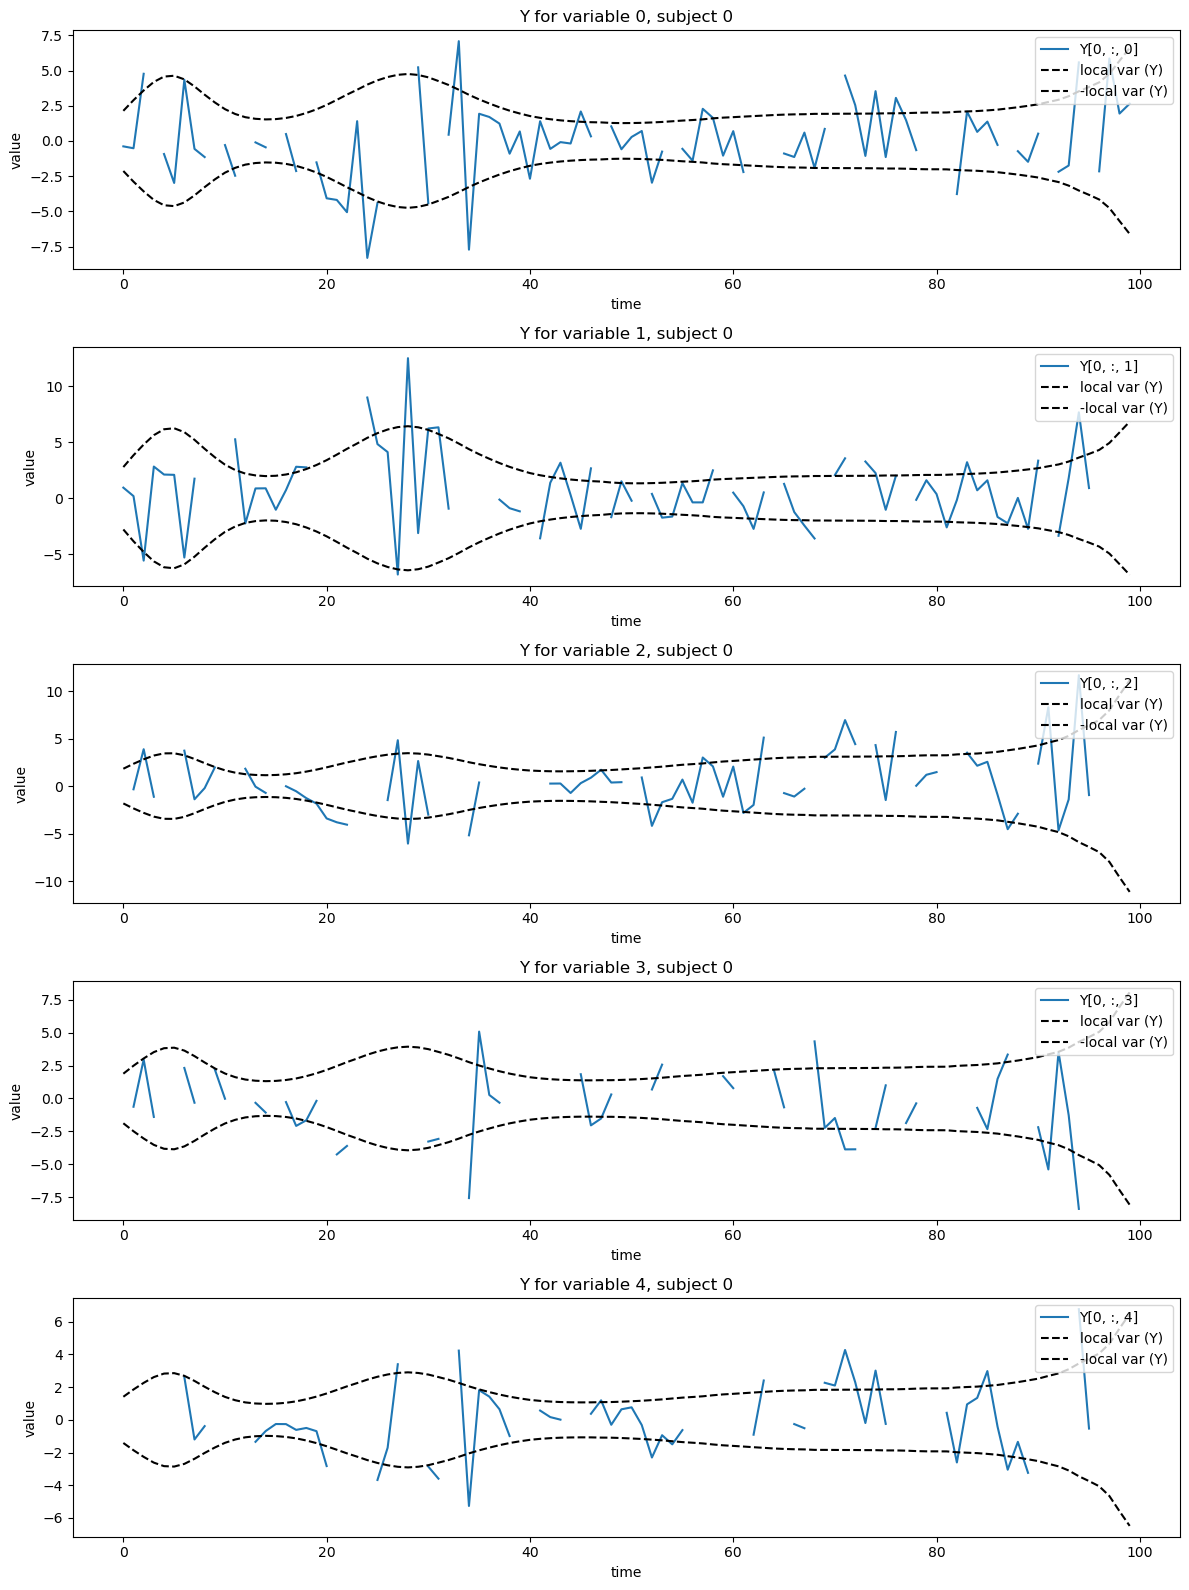

In [9]:
import copy
# Plot Y0 for subjects 0-4
plt.figure(figsize=(12, 16))
YM=copy.deepcopy(Y)
YM[M==False]=np.nan
for j in range(J):
    plt.subplot(5, 1, j + 1)
    plt.plot(YM[0, :, j], label=f"Y[0, :, {j}]")
    var = local_var_Y[0, :, j]  # shape (T,)
    plt.plot(np.sqrt(var), 'k--', label='local var (Y)')
    plt.plot(-np.sqrt(var), 'k--', label='-local var (Y)')
    plt.title(f"Y for variable {j}, subject 0")
    plt.xlabel("time")
    plt.ylabel("value")
    plt.legend(loc='upper right')
    plt.tight_layout()
plt.show()

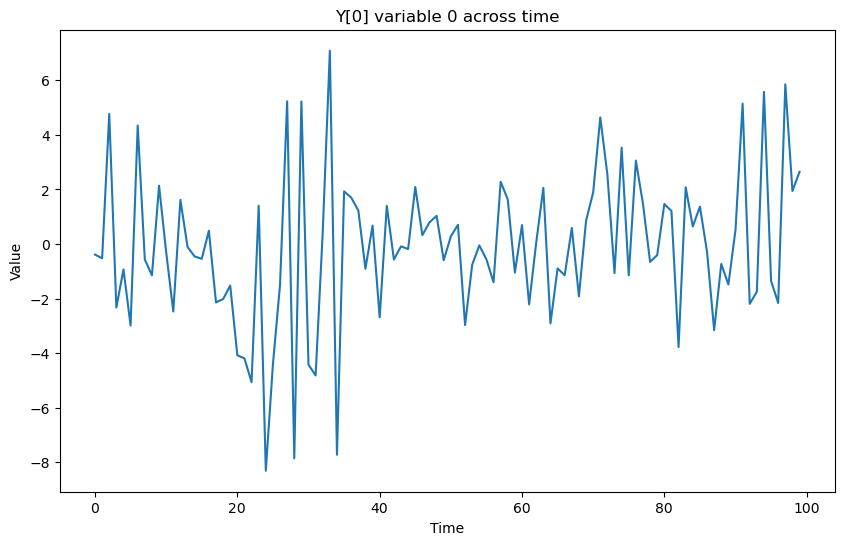

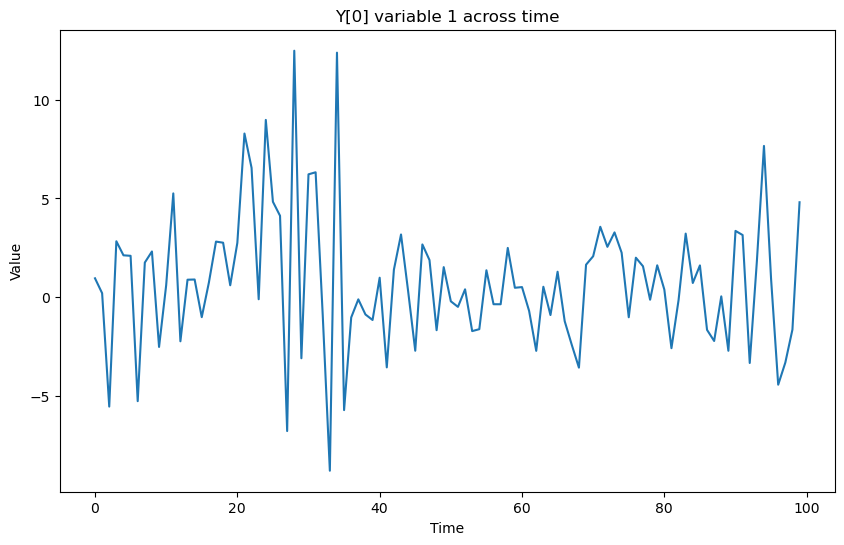

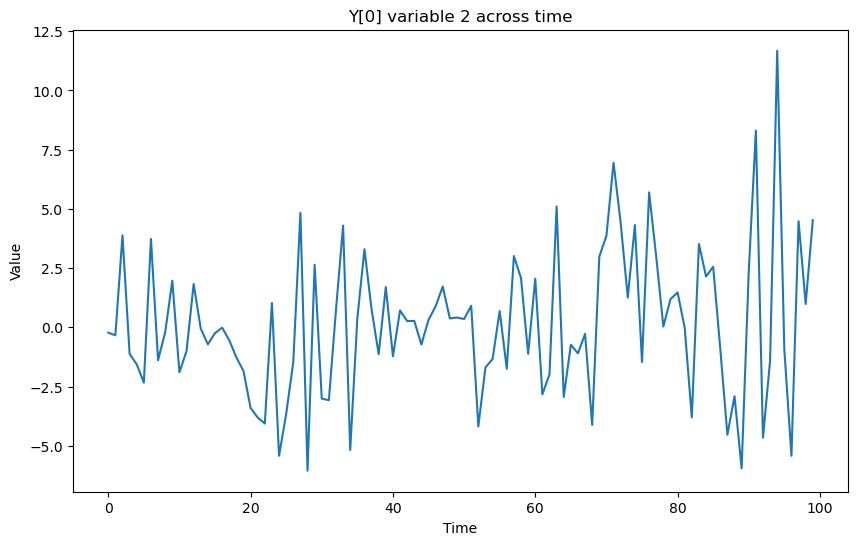

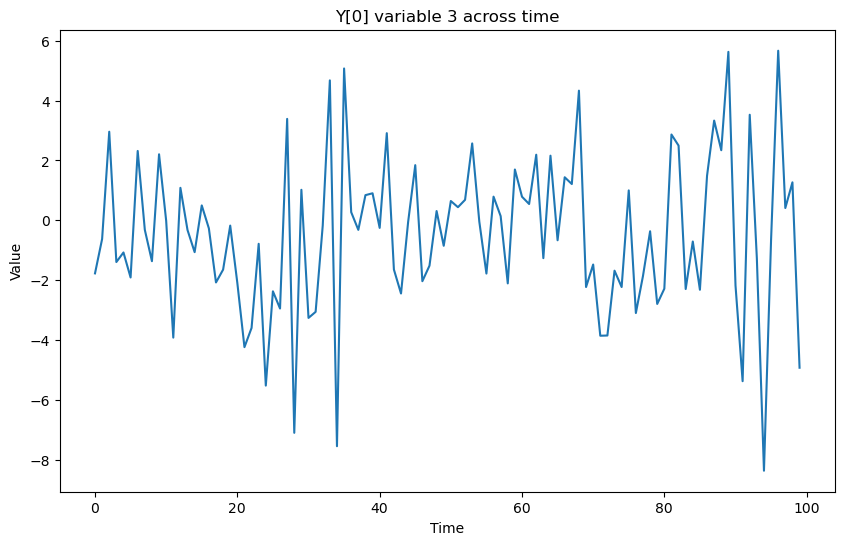

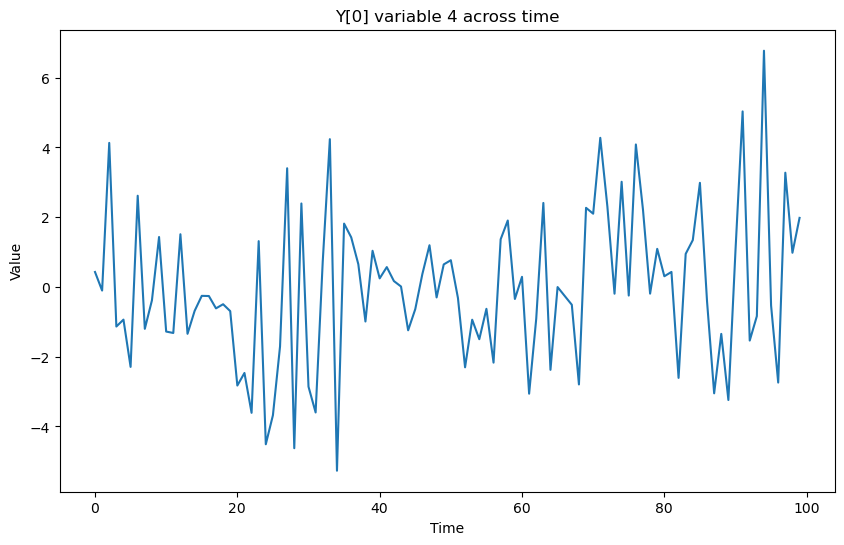

In [10]:
import matplotlib.pyplot as plt

# Plot each variable (channel) of Y[0] across time
for j in range(Y.shape[2]):
    plt.figure(figsize=(10, 6))
    plt.plot(np.arange(Y.shape[1]), Y[0, :, j])
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.title(f'Y[0] variable {j} across time')
    plt.show()

In [11]:
# --- 2) Build indices ---
obs_idx_list = []
test_idx_list = []
for i in range(I):
    for t in range(T):
        for j in range(J):
            k = flatten(i, j, t, I, J, T)
            if M[i, t, j]:
                obs_idx_list.append(k)
            else:
                test_idx_list.append(k)
obs_idx = np.array(obs_idx_list, dtype=int)
test_idx = np.array(test_idx_list, dtype=int)

# Shuffle observed indices and split into train/cal
rng = np.random.default_rng(123)
rng.shuffle(obs_idx)
split = int(0.7 * obs_idx.size)
train_idx = obs_idx[:split]
cal_idx = obs_idx[split:]

# --- 3) Simple mean predictor (per-channel mean over train observed) ---
channel_sums = np.zeros(J, dtype=float)
channel_counts = np.zeros(J, dtype=float)
for k in train_idx:
    i, j, t = unflatten(int(k), I, J, T)
    channel_sums[j] += Y[i, t, j]
    channel_counts[j] += 1.0
channel_means = channel_sums / np.clip(channel_counts, 1.0, None)

In [ ]:
info['X']

20

In [5]:
from torch._C import device
degree: int = 3
max_outer: int = 20
grad_steps: int = 5
lr: float = 1e-2
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
Y_torch = torch.as_tensor(Y, dtype=torch.float32, device=device)
M_torch = torch.as_tensor(M, dtype=torch.bool, device=device)
em_result=run_em_like(
        Y=Y_torch,
        M_mask=M_torch,
        r=r,
        M_ctrl=int(M_ctrl),
        degree=degree,
        max_outer=max_outer,
        grad_steps=grad_steps,
        lr=lr,
        device=device,
)

In [6]:
em_result

(Parameter containing:
 tensor([[-0.5308,  0.6309],
         [ 0.7425, -0.3022],
         [-0.2918,  0.7268],
         [-0.7466, -0.2462],
         [-0.2419,  0.6225]], device='cuda:0', requires_grad=True),
 tensor([0.9489, 1.0267, 1.0056, 1.0130, 0.9942], device='cuda:0',
        grad_fn=<AddBackward0>),
 tensor([1.0055, 0.9667, 0.9996, 0.9680, 0.9872, 0.9985, 1.0245, 1.0113, 1.0231,
         0.9378], device='cuda:0', grad_fn=<AddBackward0>),
 Parameter containing:
 tensor([[[ -2.8664,   0.9263,   1.0102,   0.9778,   0.9847,   0.9695,   0.9566,
             0.7811,   0.9581,   0.9917],
          [ -1.9224,   0.8638,   0.8543,   0.8160,   0.8233,   0.8215,   0.7909,
             0.8361,   1.0778,   0.9256]],
 
         [[ -1.3369,   1.0115,   0.9449,   0.9041,   0.9321,   0.9076,   0.9109,
             0.8752,   0.9321,   0.9847],
          [ -1.4840,   0.9216,   0.8250,   0.7857,   0.8193,   0.8682,   0.8639,
             0.8497,   0.7921,   0.9548]],
 
         [[ -1.7574,   0.9772, 

In [7]:
import torch
from twfv.variance import build_a2_from_C_and_warp

def local_var_from_fit(L, psi, s, C, u_tilde, knots, degree):
    with torch.no_grad():
        _, a2 = build_a2_from_C_and_warp(C, knots, degree, u_tilde)  # (I,T,r)
        base = torch.einsum("itr,jr->itj", a2, L.pow(2))             # sum_k L^2 * a2
        var = base + (s**2)[:, None, None] * psi[None, None, :]     # add noise diag
    return var  # shape (I, T, J)

In [11]:
from twfv.bspline import make_open_uniform_knots
knots = make_open_uniform_knots(M_ctrl, degree, device=device)
local_var_fitted = local_var_from_fit(em_result[0], em_result[1], em_result[2], em_result[3], em_result[4], knots, degree).cpu().numpy()

In [12]:
local_var_fitted

array([[[1.0336671 , 1.0828016 , 1.0988519 , 1.0648352 , 1.0651819 ],
        [1.0336778 , 1.0828124 , 1.0988612 , 1.0648457 , 1.0651885 ],
        [1.0387925 , 1.0850427 , 1.1050218 , 1.0667418 , 1.0696985 ],
        ...,
        [2.7833724 , 2.7519817 , 2.6685517 , 2.6717849 , 2.2061892 ],
        [2.7817903 , 2.753522  , 2.6653225 , 2.6735566 , 2.2038054 ],
        [2.723554  , 2.7546527 , 2.5794303 , 2.6800175 , 2.1406927 ]],

       [[1.0511032 , 1.124925  , 1.0820128 , 1.1068006 , 1.0323541 ],
        [1.0511135 , 1.1249427 , 1.0820173 , 1.1068182 , 1.0323573 ],
        [1.0511519 , 1.1249777 , 1.0820527 , 1.1068517 , 1.0323832 ],
        ...,
        [2.6175437 , 2.6286535 , 2.4817348 , 2.5553555 , 2.0496933 ],
        [2.666978  , 2.6628692 , 2.5337658 , 2.587069  , 2.0876694 ],
        [2.6752644 , 2.6724534 , 2.5402036 , 2.596455  , 2.0923288 ]],

       [[1.0409921 , 1.1311902 , 1.0781618 , 1.115188  , 1.0465052 ],
        [1.0434366 , 1.1318114 , 1.0813704 , 1.1156238 , 1.0

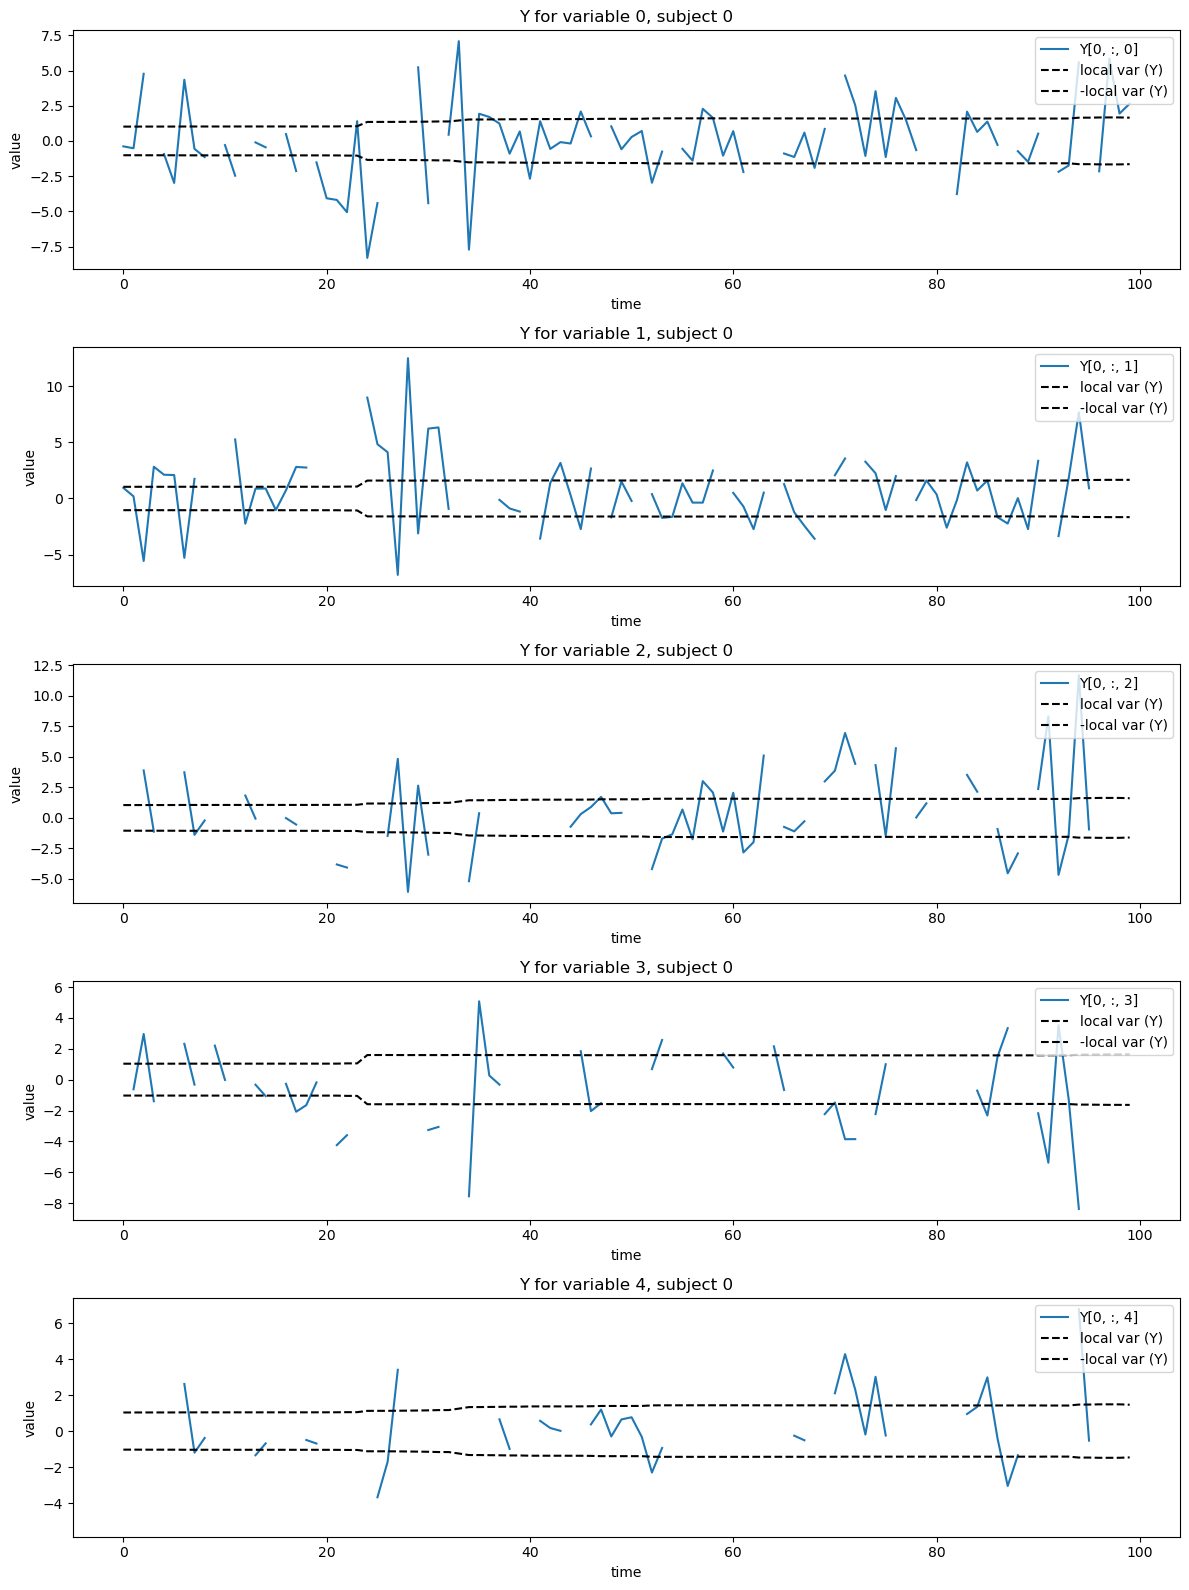

In [15]:
import copy
# Plot Y0 for subjects 0-4
plt.figure(figsize=(12, 16))
YM=copy.deepcopy(Y)
YM[M==False]=np.nan
for j in range(J):
    plt.subplot(5, 1, j + 1)
    plt.plot(YM[0, :, j], label=f"Y[0, :, {j}]")
    var = local_var_fitted[0, :, j]  # shape (T,)
    plt.plot(np.sqrt(var), 'k--', label='local var (Y)')
    plt.plot(-np.sqrt(var), 'k--', label='-local var (Y)')
    plt.title(f"Y for variable {j}, subject 0")
    plt.xlabel("time")
    plt.ylabel("value")
    plt.legend(loc='upper right')
    plt.tight_layout()
plt.show()